# Example simulation LINTUL Cassava NPK
Authors:
- Herman Berghuijs
- Tom Schut

## 1 Introduction
The aim of this notebook is to demonstrate how a LINTUL Cassava NPK simulation can be run under potential, water-limited, and water-and-nutrient-limited production. For this purpose, we will simulate a single treatment (i.e. treatment NfPfKf) of a cassava experiment done in Benue (Nigeria). In this experiment, cassava was sown in 2016. The experiment is a part of a larger set of cassava experiments grown in Nigeria (Adiele et al., 2020). The LINTUL Cassava model that is used in this Notebook is described by Adiele et al. (2022) and Ezui et al (2018).

## 2 Collect model input

First, some file paths and file names are defined for the following input files that are used in this example simulation:
  - AgroManagement file (agro_fp)
  - Crop file (crop_fp)
  - Model configuration files (conf_fp_pp, conf_fp_wlp, conf_fp_wnlp)
  - Soil file (soil_fp)
  - Site file (site_fp)
  - Weather file directory (weather_dir)
  - Weather file name (weather_fn)

In [1]:
from pathlib import Path

cwd = Path.cwd()
input_dir = cwd / "input"
agro_dir = input_dir / "agro"
agro_fp = agro_dir / "Benue_2016_NfPfKf_agro.yaml"
crop_dir = input_dir / "crop"
crop_fp = crop_dir / "cassava.yaml"
conf_dir = input_dir / "config"
conf_fp_pp = conf_dir / "Lintul_cassava10_PP.conf"
conf_fp_wlp = conf_dir / "Lintul_cassava10_WLP.conf"
conf_fp_wnlp = conf_dir / "Lintul_cassava10_WNLP.conf"
site_dir = input_dir / "site"
site_fp = site_dir / "Benue_2016_NfPfKf_site.yaml"
soil_dir = input_dir / "soil"
soil_fp = soil_dir / "Benue_2016_soil.yaml"
weather_dir = input_dir / "weather"
weather_fn = "nig2"

All input files, except for the weather files, are stored in a YAML format. Reading the content of these YAML files into a dictionary requires the yaml package, which is imported below.

In [2]:
import yaml

Next, the AgroManagement, crop, site, soil input YAML files are opened, read, and stored in dictionaries:

In [3]:
with open(crop_fp) as f:
    cropd = yaml.safe_load(f.read())
with open(agro_fp) as f:
    agrod = yaml.safe_load(f.read())
with open(soil_fp) as f:
    soild = yaml.safe_load(f.read())
with open(site_fp) as f:
    sited = yaml.safe_load(f.read())

The daily weather data and the weather station information are stored in CABO format. Reading this type of file requires the CABOWeatherDataProvider class from PCSE. Below, the daily weather data are read and stored in a CABOWeatherDataProvider object:

In [4]:
from pcse.input import CABOWeatherDataProvider
wdp = CABOWeatherDataProvider(fname=weather_fn, fpath=weather_dir)

All input files that are required to run a simulation are now loaded in a format that PCSE can read and use to run LINTUL Cassava NPK simulations. The crop, site, and soil data are combined in a ParameterProvider object, which requires the ParameterProvider class from PCSE:

In [5]:
from pcse.base import ParameterProvider
parameters = ParameterProvider(cropdata=cropd,
                               sitedata=sited,
                               soildata=soild)

## 3 Set model configuration
Next, the model configuration has to be loaded. The model configurations specifies, amongst others, which crop growth model is used for a simulation and which combination of soil water and soil nutrient model. In the first example simulation, we will run a simulation assuming potential growth using the model configuration Lintul_cassava10_PP.conf. This file has the following content:

In [6]:
with open(conf_fp_pp) as f:
    model_conf_text = f.read()
print(model_conf_text)

from lintul_cassava.lintul_cassava10 import LINTUL_CASSAVA_NO_NUTRIENT_STRESS
from lintul_cassava.lintul_cassava_soil_wrappers import Lintul_Cassava_original_PP_SoilWrapper
from pcse.agromanager import AgroManager

SOIL = Lintul_Cassava_original_PP_SoilWrapper
CROP = LINTUL_CASSAVA_NO_NUTRIENT_STRESS
AGROMANAGEMENT = AgroManager
OUTPUT_VARS = ["SM", "W", "RRD", "RD", "LAI", "WLVG", "WST", "WSO", "EVS", "TRA", "RPEVAP", "RPTRAN", "RFTRA"]
OUTPUT_INTERVAL = "daily"
OUTPUT_INTERVAL_DAYS = 1
OUTPUT_WEEKDAY = 0
SUMMARY_OUTPUT_VARS = []
TERMINAL_OUTPUT_VARS = []


The file contains a line "CROP = LINTUL_CASSAVA_NO_NUTRIENT_STRESS". This indicates that the code of the crop model that is stored in an instance of the class LINTUL_CASSAVA_NO_NUTRIENT_STRESS. In this particular simulation, the crop growth model LINTUL_CASSAVA is used assuming an absence of nutrient stress.

The line SOIL = Lintul_Cassava_original_PP_SoilWrapper indicates that the combination of the soil water module and the soil nutrient module is stored in an instance of the class Lintul_Cassava_original_PP_SoilWrapper. The "original" indicates that the original soil water module and Penman reference evapotranspiration module of LINTUL Cassava are used. The "PP" indicates that potential production is assumed. In the soil water module for potential growth, it is assumed that the amount of soil moisture in the rooted zone is always at field capacity.

Using this configuration file to build a crop-soil model require the Engine class from PCSE.

In [7]:
from pcse.engine import Engine

Building the crop-soil model also requires access to the package lintul_cassava in the parent directory of the directory where this Notebook is stored:

In [8]:
import sys
sys.path.append(str(cwd.parent))

## 3 Run simulations

Now, the LINTUL Cassava model for potential growth that is described in the configuration file can be built and initialized:

In [9]:
lintul_cassava_pp = Engine(parameters, wdp, agrod, config=conf_fp_pp)

The resulting model is run from the start until the end date:

In [10]:
lintul_cassava_pp.run_till_terminate()

And the model output is collected, stored in a dataframe. Making a dataframe requires the pandas Python package pandas:

In [11]:
import pandas as pd
output_pp = lintul_cassava_pp.get_output()
df_out_pp = pd.DataFrame(output_pp)

The model output is then stored in an Excel file for which we have to define an output path:

In [12]:
output_dir = cwd / "output"
output_pp_fp = output_dir / "output_pp.xlsx"
df_out_pp.to_excel(output_pp_fp, index = False)

The directory .../example/config also contains model configuration files to run simulations for water-limited production (Lintul_cassava10_WLP.conf) and water-and-nitrogen limited production (Lintul_cassava10_WNLP.conf). LINTUL Cassava NPK simulations can be run in a similar way as the simulation for potential growth. For water-limited production, this is done like:

In [13]:
lintul_cassava_wlp = Engine(parameters, wdp, agrod, config = conf_fp_wlp)
lintul_cassava_wlp.run_till_terminate()
output_wlp = lintul_cassava_wlp.get_output()
df_out_wlp = pd.DataFrame(output_wlp)
output_wlp_fp = output_dir / "output_wlp.xlsx"
df_out_wlp.to_excel(output_wlp_fp)

For water-and-nutrient limited growth, this is done like:

In [14]:
lintul_cassava_wnlp = Engine(parameters, wdp, agrod, config = conf_fp_wnlp)
lintul_cassava_wnlp.run_till_terminate()
output_wnlp = lintul_cassava_wnlp.get_output()
df_out_wnlp = pd.DataFrame(output_wnlp)
output_wnlp_fp = output_dir / "output_wnlp.xlsx"
df_out_wnlp.to_excel(output_wnlp_fp)

# 4 Visualize output
Finally, the model output will be visualized. The code below generates a time plot for the simulated yield under potential, water-limited, and water-and-nutrient limited conditions. Making such a plot requires the matplotlib.pyplot package.

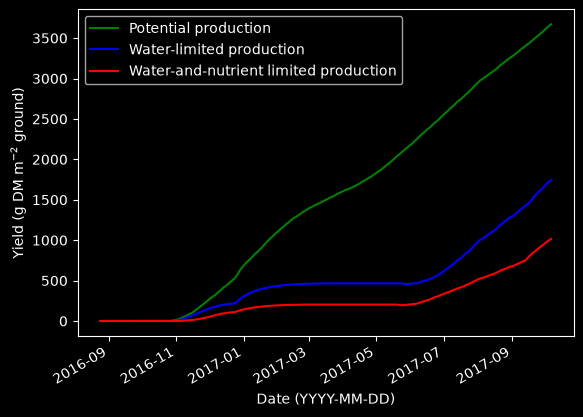

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.set_xlabel("Date (YYYY-MM-DD)")
ax.set_ylabel("Yield (g DM m$^{-2}$ ground)")
ax.plot(df_out_pp.day, df_out_pp.WSO, linestyle="-", color = 'g', label="Potential production")
ax.plot(df_out_wlp.day, df_out_wlp.WSO, linestyle="-", color = 'b', label="Water-limited production")
ax.plot(df_out_wnlp.day, df_out_wnlp.WSO, linestyle="-", color = 'r', label="Water-and-nutrient limited production")
ax.legend()
fig.autofmt_xdate()

The plot is saved to a JPEG file:

In [16]:
fig_fp = output_dir / "fig_WSO.jpeg"
fig.savefig(fig_fp, dpi = 900)

## 5 References
Adiele, J. G., Schut, A. G. T., Ezui, K. S., & Giller, K. E. (2022). LINTUL-Cassava-NPK: A simulation model for nutrient-limited cassava growth. Field Crops Research, 281, Article 108488. https://doi.org/10.1016/j.fcr.2022.108488

Adiele J.G., Schut A.G.T., Ezui K.S., Giller K.E. (2022) LINTUL-Cassava-NPK: A simulation
model for nutrient-limited cassava growth. Field Crops Research 281: ARTN 108488.
https://doi.org/10.1007/s13593-020-00649-w

Ezui K.S., Leffelaar P.A., Franke A.C., Mando A., Giller K.E. (2018) Simulating drought impact
and mitigation in cassava using the LINTUL model. Field Crops Research 219: 256-272.
https://doi.org/10.1016/j.fcr.2018.01.033